# MGMT298D: Science and Strategy of AI
## Lab 2: Tree-Based Methods for Automotive Pricing

Welcome to Lab 2! Building on your linear regression foundation from Lab 1, we'll now explore tree-based machine learning methods. These powerful algorithms can capture complex, non-linear relationships in data that linear models might miss. You'll implement decision trees, random forests, and gradient boosting models to predict Range Rover prices, then compare their performance and business implications.

## Learning Objectives
- Compare linear and non-linear approaches to predictive modeling
- Implement decision trees, random forests, and gradient boosting models
- Evaluate the trade-offs between model interpretability and performance
- Translate model insights into actionable business recommendations

## Instructions

Work through each section, execute the code cells, and answer the questions below. When complete, upload as an HTML file to BruinLearn.

---

## Setup and Data Preparation

Let's start by importing our libraries and loading the same Range Rover dataset from Lab 1. This time, we'll focus on tree-based algorithms that can handle categorical variables more naturally than linear regression.

In [5]:
import pandas as pd
import numpy as np
from sklearn import linear_model, metrics
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load datasets
train_df = pd.read_csv('range_rover_train.csv')
test_df = pd.read_csv('range_rover_test.csv')

print("Data loaded successfully!")
print(f"Training set: {train_df.shape[0]} rows, {train_df.shape[1]} columns")
print(f"Test set: {test_df.shape[0]} rows, {test_df.shape[1]} columns")

Data loaded successfully!
Training set: 263 rows, 9 columns
Test set: 112 rows, 9 columns


### Understanding Tree-Based vs Linear Methods

Before diving into the models, let's understand why tree-based methods might outperform linear regression for this problem. Tree-based models can:

- **Capture non-linear relationships**: A 2010 car might depreciate differently than a 2015 car
- **Handle interactions automatically**: High mileage might affect luxury trims differently than base models
- **Work with categorical data naturally**: No need for dummy variables

Let's prepare our data for tree-based modeling:

In [7]:
# For tree-based models, we'll use label encoding instead of dummy variables
def prepare_tree_data(df_train, df_test):
    # Create copies to avoid modifying original data
    train_encoded = df_train.copy()
    test_encoded = df_test.copy()
    
    # Initialize label encoders
    encoders = {}
    categorical_cols = ['trim', 'state', 'color']
    
    # Fit encoders on combined data to ensure consistency
    for col in categorical_cols:
        encoders[col] = LabelEncoder()
        combined_values = pd.concat([df_train[col], df_test[col]]).unique()
        encoders[col].fit(combined_values)
        
        # Transform both datasets
        train_encoded[f'{col}_encoded'] = encoders[col].transform(df_train[col])
        test_encoded[f'{col}_encoded'] = encoders[col].transform(df_test[col])
    
    # Select features for modeling
    feature_cols = ['year', 'mileage'] + [f'{col}_encoded' for col in categorical_cols]
    
    X_train = train_encoded[feature_cols]
    X_test = test_encoded[feature_cols]
    y_train = df_train['sellingprice']
    y_test = df_test['sellingprice']
    
    return X_train, X_test, y_train, y_test, encoders

X_train, X_test, y_train, y_test, encoders = prepare_tree_data(train_df, test_df)

print("Data prepared for tree-based modeling:")
print(f"Features: {list(X_train.columns)}")
print(f"Training examples: {len(X_train)}")
print(f"Test examples: {len(X_test)}")

Data prepared for tree-based modeling:
Features: ['year', 'mileage', 'trim_encoded', 'state_encoded', 'color_encoded']
Training examples: 263
Test examples: 112


## Model 1: Decision Tree Regressor

Decision trees make predictions by splitting the data based on feature values, creating a tree-like model of decisions. Let's start with a basic decision tree:

In [9]:
# Train a Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=42, max_depth=10, min_samples_split=20, min_samples_leaf=10)
dt_model.fit(X_train, y_train)

# Make predictions
dt_train_pred = dt_model.predict(X_train)
dt_test_pred = dt_model.predict(X_test)

# Calculate metrics
dt_train_mae = metrics.mean_absolute_error(y_train, dt_train_pred)
dt_test_mae = metrics.mean_absolute_error(y_test, dt_test_pred)

print("=== DECISION TREE RESULTS ===")
print(f"Training MAE: ${dt_train_mae:,.2f}")
print(f"Test MAE: ${dt_test_mae:,.2f}")
print(f"Overfitting gap (MAE): ${dt_test_mae - dt_train_mae:,.2f}")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
for idx, row in feature_importance.iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

=== DECISION TREE RESULTS ===
Training MAE: $3,013.44
Test MAE: $4,186.65
Overfitting gap (MAE): $1,173.21

Feature Importance:
  year: 0.9267
  mileage: 0.0427
  trim_encoded: 0.0304
  color_encoded: 0.0002
  state_encoded: 0.0001


## Model 2: Random Forest Regressor

Random Forest builds multiple decision trees and averages their predictions, reducing overfitting and improving generalization:

In [11]:
# Train a Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=15, 
                                   min_samples_split=10, min_samples_leaf=5, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

# Calculate metrics
rf_train_mae = metrics.mean_absolute_error(y_train, rf_train_pred)
rf_test_mae = metrics.mean_absolute_error(y_test, rf_test_pred)

print("=== RANDOM FOREST RESULTS ===")
print(f"Training MAE: ${rf_train_mae:,.2f}")
print(f"Test MAE: ${rf_test_mae:,.2f}")
print(f"Overfitting gap (MAE): ${rf_test_mae - rf_train_mae:,.2f}")

# Feature importance
rf_feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
for idx, row in rf_feature_importance.iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

=== RANDOM FOREST RESULTS ===
Training MAE: $2,266.20
Test MAE: $3,500.74
Overfitting gap (MAE): $1,234.53

Feature Importance:
  year: 0.9334
  mileage: 0.0445
  trim_encoded: 0.0204
  state_encoded: 0.0009
  color_encoded: 0.0008


## Model 3: XGBoost Regressor

XGBoost uses gradient boosting, building trees sequentially where each tree learns from the mistakes of previous trees:

In [13]:
# Train an XGBoost Regressor
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42, max_depth=6, 
                             learning_rate=0.1, subsample=0.8, colsample_bytree=0.8)
xgb_model.fit(X_train, y_train)

# Make predictions
xgb_train_pred = xgb_model.predict(X_train)
xgb_test_pred = xgb_model.predict(X_test)

# Calculate metrics
xgb_train_mae = metrics.mean_absolute_error(y_train, xgb_train_pred)
xgb_test_mae = metrics.mean_absolute_error(y_test, xgb_test_pred)

print("=== XGBOOST RESULTS ===")
print(f"Training MAE: ${xgb_train_mae:,.2f}")
print(f"Test MAE: ${xgb_test_mae:,.2f}")
print(f"Overfitting gap (MAE): ${xgb_test_mae - xgb_train_mae:,.2f}")

# Feature importance
xgb_feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
for idx, row in xgb_feature_importance.iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

=== XGBOOST RESULTS ===
Training MAE: $523.99
Test MAE: $3,405.47
Overfitting gap (MAE): $2,881.48

Feature Importance:
  year: 0.9437
  mileage: 0.0286
  trim_encoded: 0.0220
  state_encoded: 0.0030
  color_encoded: 0.0028


## Model Comparison and Analysis

Let's compare the baseline performance of all three models to identify the best starting point.

In [15]:
# Create comparison dataframe
results_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'XGBoost'],
    'Train_MAE': [dt_train_mae, rf_train_mae, xgb_train_mae],
    'Test_MAE': [dt_test_mae, rf_test_mae, xgb_test_mae],
    'Overfitting_Gap_MAE': [dt_test_mae - dt_train_mae, rf_test_mae - rf_train_mae, xgb_test_mae - xgb_train_mae]
})

print("=== BASELINE MODEL COMPARISON ===")
print(results_df.round(2))

# Identify best model based on test MAE
best_model_idx = results_df['Test_MAE'].idxmin()
best_baseline_model_name = results_df.loc[best_model_idx, 'Model']
best_baseline_test_mae = results_df.loc[best_model_idx, 'Test_MAE']

print(f"\n=== BEST BASELINE MODEL: {best_baseline_model_name} ===")
print(f"Test MAE: ${best_baseline_test_mae:,.2f}")

=== BASELINE MODEL COMPARISON ===
           Model  Train_MAE  Test_MAE  Overfitting_Gap_MAE
0  Decision Tree    3013.44   4186.65              1173.21
1  Random Forest    2266.20   3500.74              1234.53
2        XGBoost     523.99   3405.47              2881.48

=== BEST BASELINE MODEL: XGBoost ===
Test MAE: $3,405.47


## Hyperparameter Tuning: Optimizing XGBoost

Our initial comparison showed that **XGBoost** is the best baseline model. Now, let's see if we can improve its performance by systematically tuning its key hyperparameters. This process is called **hyperparameter tuning**.

We will focus on two important parameters:
- **`n_estimators`**: The number of boosting rounds or trees to build. 
- **`max_depth`**: The maximum depth of each tree, which controls model complexity.

Our goal is to find the combination that yields the **lowest Mean Absolute Error (MAE)**, making our best model even better. 🧪

--- Starting XGBoost Hyperparameter Tuning ---
  n_estimators=20, max_depth=5 -> Test MAE: $3,696.01
  n_estimators=20, max_depth=10 -> Test MAE: $3,637.96
  n_estimators=20, max_depth=20 -> Test MAE: $3,614.77
  n_estimators=20, max_depth=50 -> Test MAE: $3,614.77
  n_estimators=50, max_depth=5 -> Test MAE: $3,415.74
  n_estimators=50, max_depth=10 -> Test MAE: $3,399.83
  n_estimators=50, max_depth=20 -> Test MAE: $3,403.17
  n_estimators=50, max_depth=50 -> Test MAE: $3,403.17
  n_estimators=100, max_depth=5 -> Test MAE: $3,433.97
  n_estimators=100, max_depth=10 -> Test MAE: $3,468.82
  n_estimators=100, max_depth=20 -> Test MAE: $3,486.34
  n_estimators=100, max_depth=50 -> Test MAE: $3,483.85
  n_estimators=200, max_depth=5 -> Test MAE: $3,513.02
  n_estimators=200, max_depth=10 -> Test MAE: $3,470.66
  n_estimators=200, max_depth=20 -> Test MAE: $3,485.19
  n_estimators=200, max_depth=50 -> Test MAE: $3,482.91
  n_estimators=500, max_depth=5 -> Test MAE: $3,564.78
  n_estimators

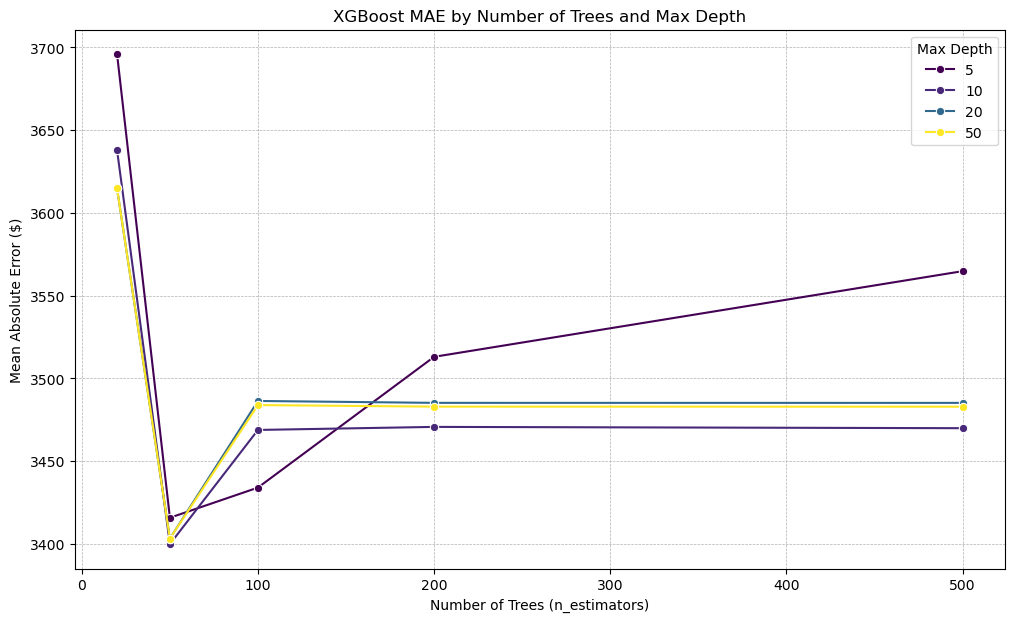

In [17]:
# Define the grid of parameters to search
param_grid = {
    'n_estimators': [20, 50, 100, 200, 500],
    'max_depth': [5, 10, 20, 50]
}

tuning_results = []
print("--- Starting XGBoost Hyperparameter Tuning ---")

# Loop through each combination of parameters
for n in param_grid['n_estimators']:
    for depth in param_grid['max_depth']:
        # Create and train the XGBoost model with the current set of parameters
        xgb_tuned = xgb.XGBRegressor(n_estimators=n, max_depth=depth, random_state=42, 
                                     learning_rate=0.1, subsample=0.8, colsample_bytree=0.8)
        xgb_tuned.fit(X_train, y_train)
        
        # Predict on the test set and calculate MAE
        y_pred = xgb_tuned.predict(X_test)
        mae = metrics.mean_absolute_error(y_test, y_pred)
        
        # Store the results
        tuning_results.append({'n_estimators': n, 'max_depth': depth, 'test_mae': mae})
        print(f"  n_estimators={n}, max_depth={depth} -> Test MAE: ${mae:,.2f}")

# Find the best performing parameters
tuning_results_df = pd.DataFrame(tuning_results)
best_params = tuning_results_df.loc[tuning_results_df['test_mae'].idxmin()]

print("\n--- Tuning Complete ---")
print(f"Best MAE: ${best_params['test_mae']:.2f}")
print(f"Best Parameters: n_estimators={int(best_params['n_estimators'])}, max_depth={int(best_params['max_depth'])}")

# Visualize the results as a line plot
plt.figure(figsize=(12, 7))
sns.lineplot(data=tuning_results_df, x='n_estimators', y='test_mae', hue='max_depth', marker='o', palette='viridis')
plt.title('XGBoost MAE by Number of Trees and Max Depth')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Mean Absolute Error ($)')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(title='Max Depth')
plt.show()

### Final Model Selection

After tuning, we compare the best tuned model's performance against our best baseline model. The winner will be used for the final analysis and business recommendations.

In [19]:
best_tuned_mae = best_params['test_mae']

print(f"Best Baseline MAE ({best_baseline_model_name}): ${best_baseline_test_mae:,.2f}")
print(f"Best Tuned MAE (XGBoost): ${best_tuned_mae:,.2f}")

# Compare and select the final model
if best_tuned_mae < best_baseline_test_mae:
    print("\nThe tuned XGBoost model performed better. Promoting it to the final model. ✅")
    best_model_name = f"XGBoost (Tuned)"
    best_test_mae = best_tuned_mae
    # Retrain the final model on the full training data with the best parameters
    best_model = xgb.XGBRegressor(
        n_estimators=int(best_params['n_estimators']),
        max_depth=int(best_params['max_depth']),
        random_state=42,
        learning_rate=0.1, 
        subsample=0.8, 
        colsample_bytree=0.8
    )
    best_model.fit(X_train, y_train)
    best_predictions = best_model.predict(X_test)
else:
    print("\nThe baseline XGBoost model remains the champion. Using it for final analysis. ✅")
    best_model_name = best_baseline_model_name
    best_test_mae = best_baseline_test_mae
    best_model = xgb_model
    best_predictions = xgb_test_pred

Best Baseline MAE (XGBoost): $3,405.47
Best Tuned MAE (XGBoost): $3,399.83

The tuned XGBoost model performed better. Promoting it to the final model. ✅


## Performance Visualization and Analysis

Now, let's create comprehensive visualizations to understand the performance of our final, champion model.

In [21]:
# Calculate detailed metrics for the final best model
mae = metrics.mean_absolute_error(y_test, best_predictions)
rmse = np.sqrt(metrics.mean_squared_error(y_test, best_predictions))
residuals = y_test - best_predictions
mean_residual = np.mean(residuals)

# Define price ranges for analysis
price_ranges = [
    ('Under $30k', y_test < 30000),
    ('$30k-$60k', (y_test >= 30000) & (y_test < 60000)),
    ('Above $60k', y_test >= 60000)
]

print(f"=== DETAILED PERFORMANCE METRICS FOR {best_model_name} ===")
print(f"Mean Absolute Error: ${mae:,.2f} (On average, our predictions are off by this amount)")
print(f"Root Mean Squared Error: ${rmse:,.2f} (Gives more weight to large errors)")
print(f"Mean Residual: ${mean_residual:,.2f} (A value near zero suggests no systematic over/under pricing)")
print(f"\nPerformance by Price Range:")
for range_name, mask in price_ranges:
    if mask.sum() > 0:
        range_mae = np.mean(np.abs(residuals[mask]))
        print(f"  {range_name}: MAE=${range_mae:,.0f} (n={mask.sum()})")

=== DETAILED PERFORMANCE METRICS FOR XGBoost (Tuned) ===
Mean Absolute Error: $3,399.83 (On average, our predictions are off by this amount)
Root Mean Squared Error: $6,002.03 (Gives more weight to large errors)
Mean Residual: $-2,564.49 (A value near zero suggests no systematic over/under pricing)

Performance by Price Range:
  Under $30k: MAE=$2,270 (n=38)
  $30k-$60k: MAE=$2,598 (n=54)
  Above $60k: MAE=$7,711 (n=20)


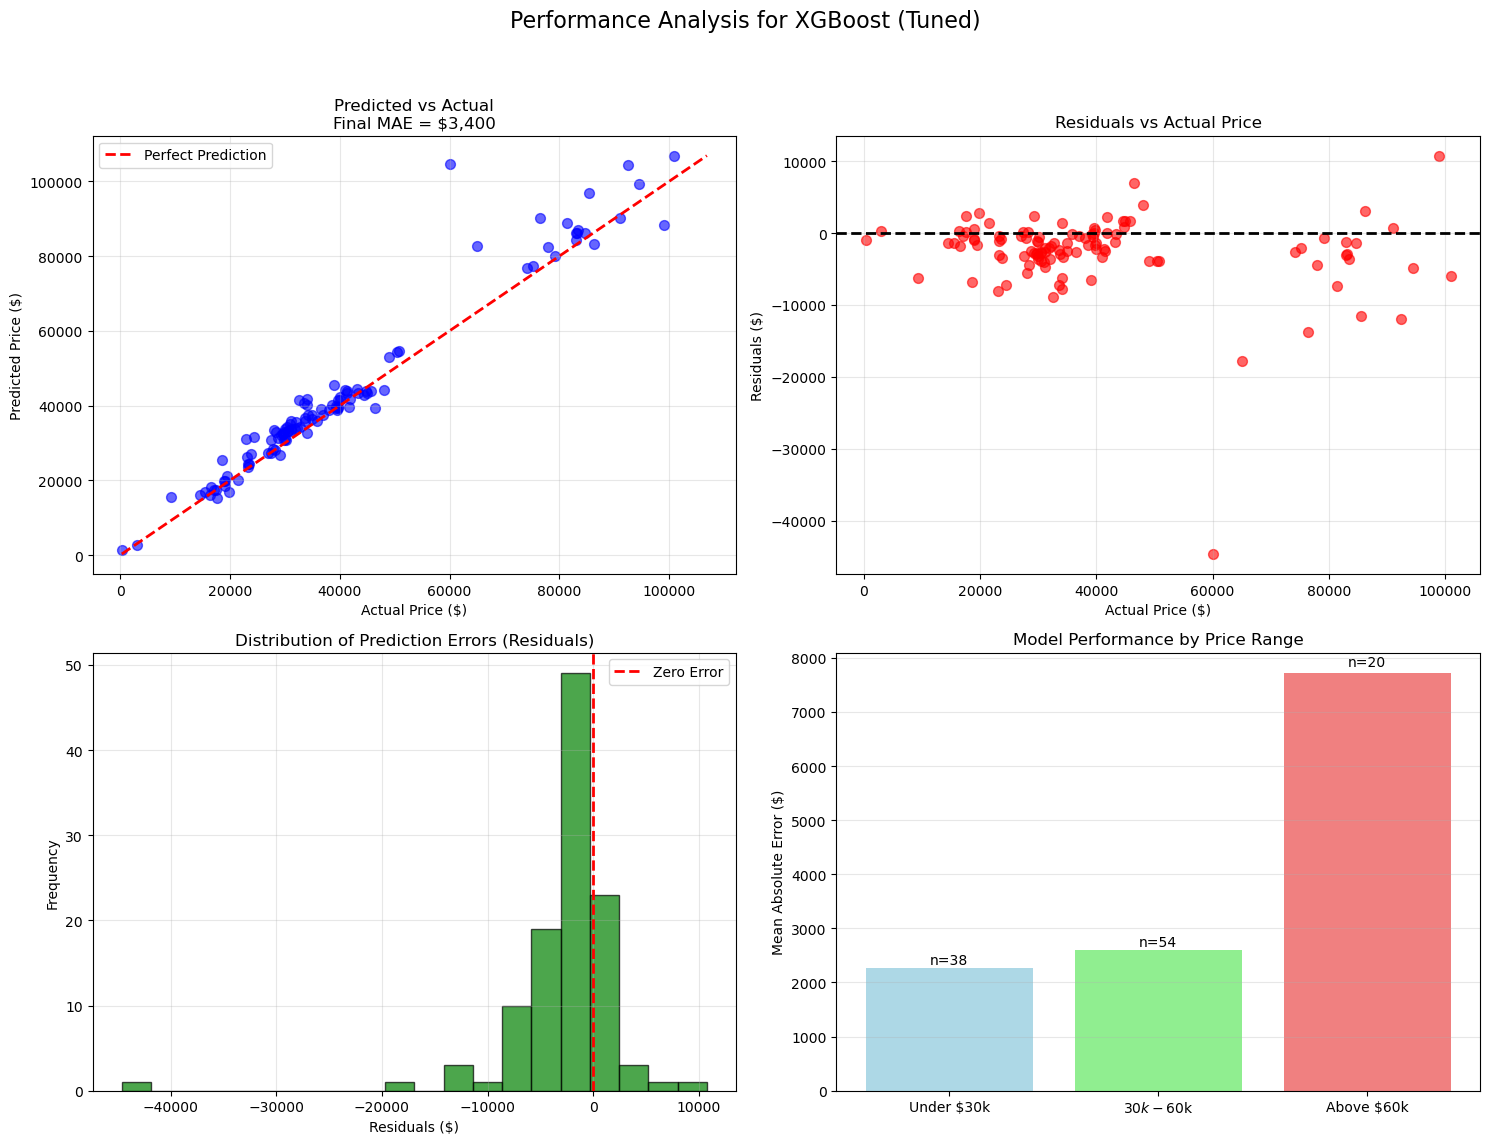

=== VISUALIZATION INSIGHTS ===
1. PREDICTION ACCURACY:
    • The final MAE of $3,400 means that, on average, the champion model's price prediction is off by that amount. This is our key measure of accuracy.

2. ERROR PATTERNS (RESIDUALS):
    • The mean residual of $-2,564 suggests a slight systematic bias in predictions.
    • The histogram shows that most errors are clustered around zero, which is ideal.

3. PRICE SEGMENT PERFORMANCE:
    • Under $30k: $2,270 average error (38 cars)
    • $30k-$60k: $2,598 average error (54 cars)
    • Above $60k: $7,711 average error (20 cars)


In [22]:
# Create comprehensive visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle(f'Performance Analysis for {best_model_name}', fontsize=16)

# Plot 1: Predicted vs Actual
ax1.scatter(y_test, best_predictions, alpha=0.6, color='blue', s=50)
min_val = min(y_test.min(), best_predictions.min())
max_val = max(y_test.max(), best_predictions.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Price ($)')
ax1.set_ylabel('Predicted Price ($)')
ax1.set_title(f'Predicted vs Actual\nFinal MAE = ${mae:,.0f}')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Residuals vs Actual
ax2.scatter(y_test, residuals, alpha=0.6, color='red', s=50)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=2)
ax2.set_xlabel('Actual Price ($)')
ax2.set_ylabel('Residuals ($)')
ax2.set_title('Residuals vs Actual Price')
ax2.grid(True, alpha=0.3)

# Plot 3: Residuals histogram
ax3.hist(residuals, bins=20, alpha=0.7, color='green', edgecolor='black')
ax3.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
ax3.set_xlabel('Residuals ($)')
ax3.set_ylabel('Frequency')
ax3.set_title('Distribution of Prediction Errors (Residuals)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Performance by price range
price_range_names = ['Under $30k', '$30k-$60k', 'Above $60k']
price_range_maes = []
price_range_counts = []
for range_name, mask in price_ranges:
    if mask.sum() > 0:
        range_mae = np.mean(np.abs(residuals[mask]))
        price_range_maes.append(range_mae)
        price_range_counts.append(mask.sum())
    else:
        price_range_maes.append(0)
        price_range_counts.append(0)
bars = ax4.bar(price_range_names, price_range_maes, color=['lightblue','lightgreen','lightcoral'])
ax4.set_ylabel('Mean Absolute Error ($)')
ax4.set_title('Model Performance by Price Range')
ax4.grid(True, alpha=0.3, axis='y')
for bar, count in zip(bars, price_range_counts):
    if count > 0:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                 f'n={count}', ha='center', va='bottom')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("=== VISUALIZATION INSIGHTS ===")
print(f"1. PREDICTION ACCURACY:")
print(f"    • The final MAE of ${mae:,.0f} means that, on average, the champion model's price prediction is off by that amount. This is our key measure of accuracy.")
print(f"\n2. ERROR PATTERNS (RESIDUALS):")
if abs(mean_residual) < 1000:
    print(f"    • The mean residual is close to zero (${mean_residual:,.0f}), which is good. It shows the model isn't systematically over- or under-predicting prices across the board.")
else:
    print(f"    • The mean residual of ${mean_residual:,.0f} suggests a slight systematic bias in predictions.")
print(f"    • The histogram shows that most errors are clustered around zero, which is ideal.")
print(f"\n3. PRICE SEGMENT PERFORMANCE:")
for range_name, mae_val, count in zip(price_range_names, price_range_maes, price_range_counts):
    if count > 0:
        print(f"    • {range_name}: ${mae_val:,.0f} average error ({count} cars)")

## Business Insights and Recommendations

Based on our final champion model, let's extract actionable business insights.

In [24]:
print(f"=== BUSINESS INSIGHTS FROM FINAL MODEL ({best_model_name}) ===")
print(f"\n1. RECOMMENDED MODEL:")
print(f"    • The final recommended model is {best_model_name}.")
print(f"    • It has an average prediction error (MAE) of ${best_test_mae:,.0f}. This provides a clear, actionable dollar value for the model's typical pricing error.")

print(f"\n2. KEY PRICING FACTORS (Feature Importance):")
# Get feature importances from the final 'best_model' object
final_feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)
top_features = final_feature_importance.head(3)

for idx, row in top_features.iterrows():
    feature_name = row['feature'].replace('_encoded', '')
    print(f"    • {feature_name.title()}: {row['importance']:.1%} importance")

print(f"\n3. PRICING ACCURACY BY SEGMENT:")
non_zero_maes = [(mae, name) for mae, name in zip(price_range_maes, price_range_names) if mae > 0]
if non_zero_maes:
    best_segment = min(non_zero_maes)[1]
    worst_segment = max(non_zero_maes)[1]
    print(f"    • Most accurate predictions (lowest MAE): {best_segment}")
    print(f"    • Least accurate predictions (highest MAE): {worst_segment}")

print(f"\n4. STRATEGIC RECOMMENDATIONS:")
print(f"    • Deploy the {best_model_name} model for automated pricing, with an expected average error of ~${best_test_mae:,.0f}.")
print(f"    • Prioritize acquisition of inventory where key drivers ({top_features.iloc[0]['feature'].replace('_encoded','')}, {top_features.iloc[1]['feature'].replace('_encoded','')}) are strong.")
if 'worst_segment' in locals():
    print(f"    • Implement a manual price review for vehicles in the '{worst_segment}' segment, as the model has higher uncertainty for these cars.")
print(f"    • Use this model to provide data-driven price estimates to customers, increasing transparency and trust.")

=== BUSINESS INSIGHTS FROM FINAL MODEL (XGBoost (Tuned)) ===

1. RECOMMENDED MODEL:
    • The final recommended model is XGBoost (Tuned).
    • It has an average prediction error (MAE) of $3,400. This provides a clear, actionable dollar value for the model's typical pricing error.

2. KEY PRICING FACTORS (Feature Importance):
    • Year: 94.8% importance
    • Trim: 2.5% importance
    • Mileage: 2.2% importance

3. PRICING ACCURACY BY SEGMENT:
    • Most accurate predictions (lowest MAE): Under $30k
    • Least accurate predictions (highest MAE): Above $60k

4. STRATEGIC RECOMMENDATIONS:
    • Deploy the XGBoost (Tuned) model for automated pricing, with an expected average error of ~$3,400.
    • Prioritize acquisition of inventory where key drivers (year, trim) are strong.
    • Implement a manual price review for vehicles in the 'Above $60k' segment, as the model has higher uncertainty for these cars.
    • Use this model to provide data-driven price estimates to customers, increasi

## Questions for Analysis

**1. Compare Performance**: How do the tree-based models compare to each other and to linear regression from Lab 1 in terms of Mean Absolute Error (MAE)? What are the trade-offs?

**2. Feature Importance**: Which features are most important for pricing predictions? How does this compare to your business intuition?

**3. Overfitting Analysis**: Which model shows the best balance between training and test performance (i.e., the smallest gap in MAE)? What does this tell you about model generalization?

**4. Business Applications**: Based on your results, what specific recommendations would you make to a used car dealership for:
  - Inventory pricing strategy
  - Acquisition decisions
  - Market positioning

**5. Model Selection**: If you had to choose one model for production use, which would you choose and why? Consider accuracy (MAE), interpretability, and computational requirements.

---

## Conclusion

In this lab, you've successfully implemented and compared three tree-based machine learning models for automotive pricing. You've learned how these non-linear methods can capture complex relationships in data and provide valuable business insights through feature importance analysis. The skills you've developed here form the foundation for more advanced machine learning applications in business strategy and operations.